# VisDrone Object Detection (YOLO, CPU) – End-to-End Notebook

This notebook sets up an end-to-end pipeline to train and evaluate a YOLO detector **on CPU** using the VisDrone dataset.

**Assumptions**
- Your project structure is like:
```
Object_detection_project/
├── VisDrone/
│   ├── train/
│   ├── valid/
│   ├── test/
│   └── data.yaml
├── notebooks/
├── models/
└── results/
```
- You are running this notebook **from inside** `Object_detection_project/notebooks`.
- Your Python environment is already activated and has `ultralytics` installed.

In [1]:
# 1) Install (if needed) and Imports
# Tip: you can re-run this cell anytime to ensure deps are available.
# Using %pip inside notebooks keeps installs tied to the current kernel.
%pip install --quiet ultralytics opencv-python matplotlib pyyaml

import yaml
import torch
from ultralytics import YOLO
from pathlib import Path
import shutil
from PIL import Image
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Note: you may need to restart the kernel to use updated packages.
PyTorch: 2.8.0+cpu
CUDA available: False
Using device: cpu


In [2]:
# 2) Paths (relative, no hardcoding of drives)
from pathlib import Path

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name.lower() == "notebooks" else ROOT

DATASET_DIR = PROJECT_ROOT / "VisDrone"
DATA_YAML = DATASET_DIR / "data.yaml"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print("Project root:", PROJECT_ROOT)
print("Dataset dir exists:", DATASET_DIR.exists())
print("data.yaml exists:", DATA_YAML.exists())

Project root: D:\Object_detection_project
Dataset dir exists: True
data.yaml exists: True


In [3]:
# 3) Quick dataset integrity checks
# - Ensure split folders exist
# - Count images/labels quickly
for split in ["train", "valid", "test"]:
    imgs = (DATASET_DIR / split / "images")
    lbls = (DATASET_DIR / split / "labels")
    print(f"[{split}] images:", imgs.exists(), "| labels:", lbls.exists())
    if imgs.exists():
        print("  image files:", len(list(imgs.glob("*"))))
    if lbls.exists():
        print("  label files:", len(list(lbls.glob("*.txt"))))

[train] images: True | labels: True
  image files: 5653
  label files: 5653
[valid] images: True | labels: True
  image files: 1614
  label files: 1614
[test] images: True | labels: True
  image files: 807
  label files: 807


In [3]:
# 4) Read data.yaml and print classes
import yaml

if not DATA_YAML.exists():
    raise FileNotFoundError("data.yaml not found at: %s" % DATA_YAML)

with open(DATA_YAML, "r") as f:
    cfg = yaml.safe_load(f)

names = cfg.get("names")
if isinstance(names, dict):  # sometimes names are given as a dict {id: name}
    names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]

print("Number of classes (nc):", cfg.get("nc", len(names) if names else "N/A"))
print("Class names:", names)

Number of classes (nc): 10
Class names: ['awning-tricycle', 'bicycle', 'bus', 'car', 'motor', 'pedestrian', 'people', 'tricycle', 'truck', 'van']


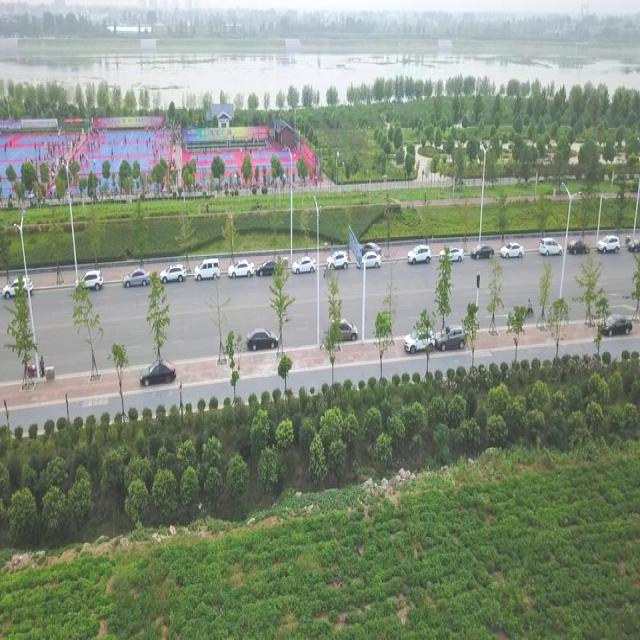

In [4]:
# 5) (Optional) Preview a sample image from the training set
from PIL import Image
from IPython.display import display
sample_img_path = next((DATASET_DIR / "train" / "images").glob("*"), None)
if sample_img_path:
    display(Image.open(sample_img_path))
else:
    print("No sample image found in train/images.")

In [5]:
# 6) Load a YOLO model (YOLOv11 if available; fallback to YOLOv8)
# We'll use a tiny (nano) checkpoint to keep CPU training feasible.
from ultralytics import YOLO
from pathlib import Path

try:
    model = YOLO("models/yolo11n.pt")   
    print("Loaded yolov11n.pt")
except Exception as e:
    print("Could not load yolov11n.pt ->", e)


Loaded yolov11n.pt


In [6]:
# 7) Sanity training run (CPU) - keep it small to verify everything works
# You can increase epochs later for real training (ideally on a GPU).
#  Define dataset and results paths
DATA_YAML = Path("D:/Object_detection_project/VisDrone/data.yaml")
RESULTS_DIR = Path("D:/Object_detection_project/results")
sanity_name = "yolo_n_visdrone_sanity_cpu"
results = model.train(
    data=str(DATA_YAML),
    epochs=1,          # quick test run
    imgsz=256,
    batch=2,           # small batch for CPU
    device="cpu",
    project=str(RESULTS_DIR),
    name=sanity_name,
    pretrained=True,
    fraction=0.01  # use only 1% of dataset
)
print("Sanity training complete. Results saved to:", RESULTS_DIR / sanity_name)

Ultralytics 8.3.179  Python-3.12.1 torch-2.8.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Object_detection_project\VisDrone\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.01, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_n_visdrone_sanity_cpu4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

train: Scanning D:\Object_detection_project\Visdrone\train\labels.cache... 57 images, 0 backgrounds, 0 corrupt: 100%|██

val: Fast image access  (ping: 0.60.2 ms, read: 5.70.8 MB/s, size: 73.1 KB)



D:\Object_detection_project\env\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning D:\Object_detection_project\Visdrone\valid\labels.cache... 1614 images, 0 backgrounds, 0 corrupt: 100%|██

val: D:\Object_detection_project\Visdrone\valid\images\9999945_00000_d_0000114_jpg.rf.6d2403991e64c575115b80efa318f49e.jpg: 1 duplicate labels removed


...

Plotting labels to D:\Object_detection_project\results\yolo_n_visdrone_sanity_cpu4\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 256 train, 256 val
Using 0 dataloader workers
Logging results to D:\Object_detection_project\results\yolo_n_visdrone_sanity_cpu4
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1         0G      2.961      4.682      1.545          8        256: 100%|██████████| 29/29 [00:09<00:00,  2.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 404/404 [01:


                   all       1614      82443   0.000194    0.00202   0.000108   5.08e-05

1 epochs completed in 0.035 hours.
Optimizer stripped from D:\Object_detection_project\results\yolo_n_visdrone_sanity_cpu4\weights\last.pt, 5.4MB
Optimizer stripped from D:\Object_detection_project\results\yolo_n_visdrone_sanity_cpu4\weights\best.pt, 5.4MB

Validating D:\Object_detection_project\results\yolo_n_visdrone_sanity_cpu4\weights\best.pt...
Ultralytics 8.3.179  Python-3.12.1 torch-2.8.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 404/404 [01:


                   all       1614      82443   0.000197    0.00203   0.000109   5.03e-05
       awning-tricycle        273        690   2.14e-05    0.00145   1.07e-05   1.07e-06
               bicycle        611       2196          0          0          0          0
                   bus        564       1701   0.000215    0.00412   0.000133   9.45e-05
                   car       1528      35206   0.000668   0.000653   0.000337   0.000114
                 motor        989       6591          0          0          0          0
            pedestrian       1326      19578   4.36e-05   0.000102   6.62e-05   3.99e-05
                people        955       6385          0          0          0          0
              tricycle        358        961          0          0          0          0
                 truck        845       3048    0.00084     0.0128   0.000446   0.000219
                   van       1222       6087   0.000179    0.00115   9.93e-05   3.44e-05
Speed: 0.3ms preproce

In [7]:
# 8) Validation on the validation set (computes mAP, precision, recall, F1, etc.)
val_name = "val_" + sanity_name
metrics = model.val(
    data=str(DATA_YAML),
    device="cpu",
    project=str(RESULTS_DIR),
    name=val_name
)

# Print key metrics
print("mAP50-95:", getattr(metrics.box, "map", None))
print("mAP50   :", getattr(metrics.box, "map50", None))
print("mAP75   :", getattr(metrics.box, "map75", None))
print("Per-class mAP50-95 list:", getattr(metrics.box, "maps", None))

# Where to find plots/images:
print("Validation outputs saved to:", RESULTS_DIR / val_name)

Ultralytics 8.3.179  Python-3.12.1 torch-2.8.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 124.79.6 MB/s, size: 61.6 KB)


val: Scanning D:\Object_detection_project\Visdrone\valid\labels.cache... 1614 images, 0 backgrounds, 0 corrupt: 100%|██

val: D:\Object_detection_project\Visdrone\valid\images\9999945_00000_d_0000114_jpg.rf.6d2403991e64c575115b80efa318f49e.jpg: 1 duplicate labels removed



D:\Object_detection_project\env\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 807/807 [01:


                   all       1614      82443   0.000197    0.00203   0.000109   5.03e-05
       awning-tricycle        273        690   2.14e-05    0.00145   1.07e-05   1.07e-06
               bicycle        611       2196          0          0          0          0
                   bus        564       1701   0.000215    0.00412   0.000133   9.45e-05
                   car       1528      35206   0.000668   0.000653   0.000337   0.000114
                 motor        989       6591          0          0          0          0
            pedestrian       1326      19578   4.36e-05   0.000102   6.62e-05   3.99e-05
                people        955       6385          0          0          0          0
              tricycle        358        961          0          0          0          0
                 truck        845       3048    0.00084     0.0128   0.000446   0.000219
                   van       1222       6087   0.000179    0.00115   9.93e-05   3.44e-05
Speed: 0.3ms preproce


image 1/1 D:\Object_detection_project\VisDrone\train\images\0000003_00231_d_0000016_jpg.rf.d1617c6ef92430e0dd6f235275d20075.jpg: 640x640 17 cars, 100.9ms
Speed: 3.7ms preprocess, 100.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)


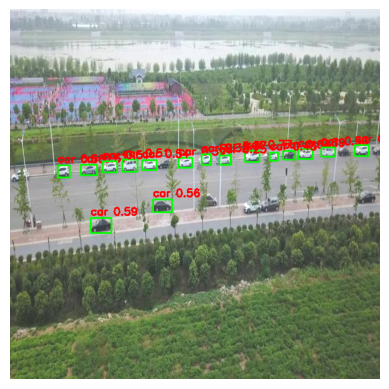

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load model
model = YOLO("yolo11n.pt")  # or your trained weights

# Predict on one image
image_path = r"D:\Object_detection_project\VisDrone\train\images\0000003_00231_d_0000016_jpg.rf.d1617c6ef92430e0dd6f235275d20075.jpg"
results = model.predict(image_path, save=False)

# Read image
im = cv2.imread(image_path)
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# If detections exist, plot them
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls = int(box.cls[0].cpu().numpy())
        conf = float(box.conf[0].cpu().numpy())
        label = f"{model.names[cls]} {conf:.2f}"
        cv2.rectangle(im, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
        cv2.putText(im, label, (int(x1), int(y1)-5), cv2.FONT_HERSHEY_SIMPLEX, 
                    0.6, (255,0,0), 2)

# Show image
plt.imshow(im)
plt.axis("off")
plt.show()


In [ ]:
# 11) Copy best weights to ../models for safekeeping
weights_path = RESULTS_DIR / sanity_name / "weights" / "best.pt"
dest_path = MODELS_DIR / "best_yolo_visdrone_cpu.pt"
if weights_path.exists():
    shutil.copy2(weights_path, dest_path)
    print("Saved best weights to:", dest_path)
else:
    print("Weights not found at:", weights_path)

## 🔁 Next Steps (when you're ready)
- Increase training epochs (e.g., 50–200) – preferably on a GPU for speed.
- Try a larger model (`yolov11s.pt`, `yolov11m.pt`) if accuracy is not enough.
- Adjust hyperparameters: `lr0`, `lrf`, `momentum`, `weight_decay`, `box`, `cls`, `dfl`, `hsv_h/s/v`, `mosaic`, etc.
- Use `imgsz=1280` for higher-resolution training if your machine can handle it.
- Track experiments in the `results/` folder and keep best weights in `models/`.